# SemiDAViL: Semi-supervised Domain Adaptation with Vision-Language Guidance


## Architecture Overview
1. **CLIP Encoder** — extracts visual + text features
2. **Dense Language Guidance (DLG)** — fuses vision & language via cross-attention
3. **Segmentation Decoder** — produces pixel-wise predictions
4. **Student-Teacher Framework** — EMA-based consistency on unlabeled data
5. **DyCE Loss** — dynamic cross-entropy for class imbalance
6. **Consistency Loss** — enforces agreement on unlabeled data

In [1]:
# install required packages
!pip install -q ftfy regex tqdm open_clip_torch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.4 MB/s eta 0:00:00a 0:00:01


---
## Cell 2: Imports & Device Setup

In [2]:
# all imports in one place
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import open_clip
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
## Cell 3: Configuration
All hyperparameters and paths in one place.

In [33]:
# ---- paths (update for kaggle) ----
# ---- paths (kaggle) ----
# ---- paths (kaggle) ----
TRAIN_IMG_DIR = '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images'
TRAIN_MASK_DIR = '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks'
TEST_IMG_DIR = '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images'
TEST_MASK_DIR = '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks'



# ---- model config ----
IMG_SIZE = 352               # input resolution
NUM_CLASSES = 1              # binary segmentation (polyp vs bg)
CLIP_MODEL = 'ViT-B-16'     # CLIP backbone
CLIP_PRETRAINED = 'openai'  # pretrained weights

# ---- training config ----
BATCH_SIZE = 4
NUM_EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-4
LABELED_RATIO = 0.5          # 50% labeled, 50% pseudo-labeled

# ---- loss config ----
DYCE_HARD_PCT = 0.2          # top 20% hardest pixels
DYCE_OMEGA = 0.5             # class-balance weight
PSEUDO_THRESHOLD = 0.95      # confidence for pseudo-labels

# ---- teacher EMA ----
EMA_ALPHA = 0.999

# ---- text prompts for DLG ----
CLASS_PROMPTS = [
    'a colonoscopy image showing healthy colon tissue',
    'a colonoscopy image showing a polyp'
]

print('Config loaded.')

Config loaded.


---
## Cell 4: Dataset Class
Loads images + masks with augmentations for polyp segmentation.

In [8]:
# run this to find exact folder structure
import os
for base in ['/kaggle/input/datasets/longvil/cvc-colondb', '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb']:
    print(f'\n--- {base} ---')
    for root, dirs, files in os.walk(base):
        level = root.replace(base, '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')



--- /kaggle/input/datasets/longvil/cvc-colondb ---
cvc-colondb/ (0 files)
  CVC-ColonDB/ (0 files)
    images/ (380 files)
    masks/ (380 files)

--- /kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb ---
etis-laribpolypdb/ (0 files)
  images/ (196 files)
  masks/ (196 files)


In [34]:
class PolypDataset(Dataset):
    """Dataset for polyp segmentation."""
    def __init__(self, img_dir, mask_dir, img_size=352, augment=False):
        # collect all image paths
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, '*')))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*')))
        self.img_size = img_size
        self.augment = augment
        
        # augmentation pipeline
        if augment:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(img_size, img_size),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
    
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        # load image and mask
        img = np.array(Image.open(self.img_paths[idx]).convert('RGB'))
        mask = np.array(Image.open(self.mask_paths[idx]).convert('L'))
        
        # binarize mask (0 or 1)
        mask = (mask > 127).astype(np.float32)
        
        # apply transforms
        transformed = self.transform(image=img, mask=mask)
        img = transformed['image']          # (3, H, W)
        mask = transformed['mask']           # (H, W)
        mask = mask.unsqueeze(0).float()     # (1, H, W)
        
        return img, mask

print('PolypDataset class defined.')

PolypDataset class defined.


---
## Cell 5: Create DataLoaders
Splits training data into labeled + unlabeled sets.

In [35]:
# full training dataset
full_train = PolypDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE, augment=True)

# split into labeled and unlabeled
n_total = len(full_train)
n_labeled = int(n_total * LABELED_RATIO)
n_unlabeled = n_total - n_labeled

labeled_set, unlabeled_set = torch.utils.data.random_split(
    full_train, [n_labeled, n_unlabeled],
    generator=torch.Generator().manual_seed(SEED)
)

# dataloaders
labeled_loader = DataLoader(labeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

# test dataset
test_dataset = PolypDataset(TEST_IMG_DIR, TEST_MASK_DIR, IMG_SIZE, augment=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f'Labeled: {n_labeled} | Unlabeled: {n_unlabeled} | Test: {len(test_dataset)}')

Labeled: 190 | Unlabeled: 190 | Test: 196


---
## Cell 6: Dense Language Guidance (DLG) Module
Fuses visual features with text embeddings via cross-attention (Section 3.2 of paper).

In [36]:
class DenseLanguageGuidance(nn.Module):
    """Cross-modal fusion of vision and language features."""
    def __init__(self, embed_dim, num_heads=8):
        super().__init__()
        # project vision & text to same space
        self.vis_proj = nn.Linear(embed_dim, embed_dim)
        self.lang_proj = nn.Linear(embed_dim, embed_dim)
        
        # vision-to-language cross-attention
        self.v2l_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.v2l_norm = nn.LayerNorm(embed_dim)
        
        # language-to-vision cross-attention
        self.l2v_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.l2v_norm = nn.LayerNorm(embed_dim)
        
        # fusion mlp
        self.fusion_mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )
        self.out_norm = nn.LayerNorm(embed_dim)
    
    def forward(self, vis_tokens, lang_tokens):
        # vis_tokens: (B, N, D), lang_tokens: (B, T, D)
        v = self.vis_proj(vis_tokens)
        l = self.lang_proj(lang_tokens)
        
        # vision attends to language (query=vision, key/value=language)
        v2l, _ = self.v2l_attn(v, l, l)
        v2l = self.v2l_norm(v + v2l)
        
        # language attends to vision (query=language, key/value=vision)
        l2v, _ = self.l2v_attn(l, v, v)
        l2v = self.l2v_norm(l + l2v)
        
        # expand language features to match spatial dims
        l2v_expanded = l2v.mean(dim=1, keepdim=True).expand_as(v2l)
        
        # fuse both streams
        fused = self.fusion_mlp(torch.cat([v2l, l2v_expanded], dim=-1))
        fused = self.out_norm(vis_tokens + fused)
        
        return fused

print('DLG module defined.')

DLG module defined.


---
## Cell 7: Segmentation Decoder
Converts fused feature maps to pixel-wise predictions.

In [37]:
class SegmentationDecoder(nn.Module):
    """Decodes fused features into segmentation map."""
    def __init__(self, in_channels, num_classes=1):
        super().__init__()
        self.decode = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
    
    def forward(self, x, target_size):
        # x: (B, C, h, w) -> decode and upsample
        x = self.decode(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        return x

print('SegmentationDecoder defined.')

SegmentationDecoder defined.


---
## Cell 8: SemiDAViL Model
Main model with CLIP backbone, DLG fusion, decoder, and student-teacher setup.

In [39]:
class SemiDAViL(nn.Module):
    """Full SemiDAViL model for polyp segmentation."""
    def __init__(self, num_classes=1, clip_model_name='ViT-B-16', pretrained='openai'):
        super().__init__()
        
        # load CLIP model (frozen)
        self.clip, _, self.clip_preprocess = open_clip.create_model_and_transforms(
            clip_model_name, pretrained=pretrained
        )
        self.tokenizer = open_clip.get_tokenizer(clip_model_name)
        self.clip.eval()
        for p in self.clip.parameters():
            p.requires_grad = False
        
        # get feature dimension from CLIP
        self.feat_dim = self.clip.visual.output_dim  # 512 for ViT-B-16
        self.patch_size = self.clip.visual.conv1.kernel_size[0]  # 16
        
        # student network: DLG + decoder
        self.student_dlg = DenseLanguageGuidance(self.feat_dim)
        self.student_decoder = SegmentationDecoder(self.feat_dim, num_classes)
        
        # teacher network: DLG + decoder (same architecture)
        self.teacher_dlg = DenseLanguageGuidance(self.feat_dim)
        self.teacher_decoder = SegmentationDecoder(self.feat_dim, num_classes)
        
        # init teacher with student weights, freeze gradients
        self._init_teacher()
    
    def _init_teacher(self):
        """Copy student weights to teacher, disable teacher gradients."""
        for sp, tp in zip(self._student_params(), self._teacher_params()):
            tp.data.copy_(sp.data)
            tp.requires_grad = False
    
    def _student_params(self):
        return list(self.student_dlg.parameters()) + list(self.student_decoder.parameters())
    
    def _teacher_params(self):
        return list(self.teacher_dlg.parameters()) + list(self.teacher_decoder.parameters())
    
    def get_trainable_params(self):
        """Only student params are trained."""
        return self._student_params()
    
    @torch.no_grad()
    def encode_text_prompts(self, prompts, device):
        """Encode text prompts using CLIP text encoder."""
        tokens = self.tokenizer(prompts).to(device)
        text_feats = self.clip.encode_text(tokens)  # (T, D)
        text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
        return text_feats
    
    @torch.no_grad()
    def extract_visual_tokens(self, images):
        """Extract patch tokens with positional embedding interpolation."""
        B, _, H, W = images.shape
        
        # patch embed via conv1
        x = self.clip.visual.conv1(images)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # (B, N, D)
        
        # add class token
        cls_token = self.clip.visual.class_embedding.unsqueeze(0).unsqueeze(0).expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)  # (B, N+1, D)
        
        # interpolate positional embeddings to match new resolution
        pos_embed = self.clip.visual.positional_embedding.unsqueeze(0)  # (1, 197, D)
        cls_pos = pos_embed[:, :1, :]       # (1, 1, D)
        patch_pos = pos_embed[:, 1:, :]     # (1, 196, D)
        
        # original grid size (14x14 for 224/16)
        orig_size = int(patch_pos.shape[1] ** 0.5)  # 14
        new_h, new_w = H // self.patch_size, W // self.patch_size
        
        # reshape and interpolate to new grid size
        patch_pos = patch_pos.reshape(1, orig_size, orig_size, -1).permute(0, 3, 1, 2)
        patch_pos = F.interpolate(patch_pos, size=(new_h, new_w), mode='bicubic', align_corners=False)
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, new_h * new_w, -1)
        
        # concat cls + interpolated patch positions
        pos_embed = torch.cat([cls_pos, patch_pos], dim=1)
        x = x + pos_embed
        
        # pass through transformer
        x = self.clip.visual.patch_dropout(x)
        x = self.clip.visual.ln_pre(x)
        x = self.clip.visual.transformer(x)
        
        # remove CLS, keep patch tokens
        patch_tokens = x[:, 1:, :]
        patch_tokens = patch_tokens @ self.clip.visual.proj
        
        return patch_tokens
    
    def forward(self, images, text_feats, network='student'):
        B, _, H, W = images.shape
        
        # extract visual patch tokens from CLIP
        vis_tokens = self.extract_visual_tokens(images)  # (B, N, D)
        
        # expand text features for batch
        lang_tokens = text_feats.unsqueeze(0).expand(B, -1, -1)  # (B, T, D)
        
        # select student or teacher
        if network == 'student':
            fused = self.student_dlg(vis_tokens, lang_tokens)
            decoder = self.student_decoder
        else:
            with torch.no_grad():
                fused = self.teacher_dlg(vis_tokens, lang_tokens)
            decoder = self.teacher_decoder
        
        # reshape to 2D feature map: (B, N, D) -> (B, D, h, w)
        h, w = H // self.patch_size, W // self.patch_size
        feat_map = fused.permute(0, 2, 1).reshape(B, self.feat_dim, h, w)
        
        # decode to segmentation map
        logits = decoder(feat_map, target_size=(H, W))
        
        return logits

print('SemiDAViL model defined.')


SemiDAViL model defined.


---
## Cell 9: DyCE Loss (Dynamic Cross-Entropy)
Focuses on hardest pixels and reweights to handle class imbalance (Section 3.4).

In [40]:
class DyCELoss(nn.Module):
    """Dynamic Cross-Entropy loss for hard pixel mining."""
    def __init__(self, hard_pct=0.2, omega=0.5):
        super().__init__()
        self.hard_pct = hard_pct
        self.omega = omega
    
    def forward(self, logits, targets):
        # logits: (B, 1, H, W), targets: (B, 1, H, W)
        # compute BCE loss per pixel
        per_pixel = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        flat_loss = per_pixel.view(-1)
        flat_targets = targets.view(-1)
        
        if flat_loss.numel() == 0:
            return torch.tensor(0.0, device=logits.device)
        
        # mine top-k hardest pixels
        k = max(1, int(self.hard_pct * flat_loss.numel()))
        hard_losses, hard_idx = torch.topk(flat_loss, k)
        hard_targets = flat_targets[hard_idx]
        
        # class frequency in hard set
        n_pos = hard_targets.sum() + 1e-8
        n_neg = (1 - hard_targets).sum() + 1e-8
        f_H = float(k)
        
        # dynamic weights per pixel
        weights = torch.where(
            hard_targets > 0.5,
            1.0 / (n_pos ** (1 - self.omega)),
            1.0 / (n_neg ** (1 - self.omega))
        )
        
        # volume-weighted loss
        volume_w = 1.0 / (f_H ** self.omega)
        loss = volume_w * (weights * hard_losses).sum()
        
        return loss

print('DyCE Loss defined.')

DyCE Loss defined.


---
## Cell 10: Consistency Loss
Forces student to match teacher's high-confidence predictions on unlabeled data (Section 3.3).

In [41]:
class ConsistencyLoss(nn.Module):
    """Student-teacher consistency on unlabeled data."""
    def __init__(self, threshold=0.95):
        super().__init__()
        self.threshold = threshold
    
    def forward(self, student_logits, teacher_logits):
        # teacher predictions as pseudo-labels
        teacher_probs = torch.sigmoid(teacher_logits.detach())
        
        # high-confidence mask (teacher is confident)
        confidence = torch.max(teacher_probs, 1 - teacher_probs)
        mask = (confidence >= self.threshold).float()
        
        if mask.sum() == 0:
            return torch.tensor(0.0, device=student_logits.device)
        
        # binary pseudo-labels from teacher
        pseudo_labels = (teacher_probs > 0.5).float()
        
        # BCE on confident pixels only
        per_pixel = F.binary_cross_entropy_with_logits(student_logits, pseudo_labels, reduction='none')
        masked_loss = (per_pixel * mask).sum() / mask.sum()
        
        return masked_loss

print('Consistency Loss defined.')

Consistency Loss defined.


---
## Cell 11: Dice + BCE Combined Loss
Additional supervised loss for better segmentation quality.

In [42]:
class DiceBCELoss(nn.Module):
    """Dice + BCE combination for segmentation."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        flat_p = probs.view(-1)
        flat_t = targets.view(-1)
        
        # dice loss
        intersection = (flat_p * flat_t).sum()
        dice = 1 - (2 * intersection + self.smooth) / (flat_p.sum() + flat_t.sum() + self.smooth)
        
        # bce loss
        bce = F.binary_cross_entropy_with_logits(logits, targets)
        
        return dice + bce

print('DiceBCE Loss defined.')

DiceBCE Loss defined.


---
## Cell 12: EMA Update for Teacher
Updates teacher weights as exponential moving average of student (Eq. 6 in paper).

In [43]:
@torch.no_grad()
def update_teacher_ema(student_params, teacher_params, alpha=0.999):
    """θ_T = α * θ_T + (1-α) * θ_S"""
    for sp, tp in zip(student_params, teacher_params):
        tp.data.mul_(alpha).add_(sp.data, alpha=1 - alpha)

print('EMA updater defined.')

EMA updater defined.


---
## Cell 13: Evaluation Metrics
Dice Score, IoU, Precision, Recall for polyp segmentation.

In [44]:
def compute_metrics(pred, target, threshold=0.5):
    """Compute dice, iou, precision, recall."""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    # flatten
    p = pred.view(-1)
    t = target.view(-1)
    
    tp = (p * t).sum()
    fp = (p * (1 - t)).sum()
    fn = ((1 - p) * t).sum()
    
    # dice
    dice = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    
    # iou
    iou = (tp + 1e-8) / (tp + fp + fn + 1e-8)
    
    # precision & recall
    precision = (tp + 1e-8) / (tp + fp + 1e-8)
    recall = (tp + 1e-8) / (tp + fn + 1e-8)
    
    return {
        'dice': dice.item(),
        'iou': iou.item(),
        'precision': precision.item(),
        'recall': recall.item()
    }

print('Metrics function defined.')

Metrics function defined.


---
## Cell 14: Initialize Model, Optimizer, Losses

In [45]:
# create model
model = SemiDAViL(num_classes=NUM_CLASSES, clip_model_name=CLIP_MODEL, pretrained=CLIP_PRETRAINED).to(DEVICE)

# encode class prompts once (reused every iteration)
text_feats = model.encode_text_prompts(CLASS_PROMPTS, DEVICE)  # (2, 512)

# optimizer (only student params)
optimizer = torch.optim.AdamW(model.get_trainable_params(), lr=LR, weight_decay=WEIGHT_DECAY)

# learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# loss functions
dyce_loss_fn = DyCELoss(hard_pct=DYCE_HARD_PCT, omega=DYCE_OMEGA)
consistency_loss_fn = ConsistencyLoss(threshold=PSEUDO_THRESHOLD)
dicebce_loss_fn = DiceBCELoss()

# count trainable params
n_params = sum(p.numel() for p in model.get_trainable_params())
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 4,966,785


---
## Cell 15: Training Loop
Combines supervised (DyCE + DiceBCE) and unsupervised (consistency) losses.
Teacher is updated via EMA after each step.

In [46]:
# training history
history = {'train_loss': [], 'sup_loss': [], 'con_loss': [], 'val_dice': []}
best_dice = 0.0

for epoch in range(NUM_EPOCHS):
    model.student_dlg.train()
    model.student_decoder.train()
    
    epoch_loss, epoch_sup, epoch_con = 0, 0, 0
    n_batches = 0
    
    # create iterators
    labeled_iter = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)
    n_steps = min(len(labeled_loader), len(unlabeled_loader))
    
    pbar = tqdm(range(n_steps), desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    
    for step in pbar:
        # -- fetch labeled batch --
        try:
            imgs_l, masks_l = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            imgs_l, masks_l = next(labeled_iter)
        
        # -- fetch unlabeled batch --
        try:
            imgs_u, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            imgs_u, _ = next(unlabeled_iter)
        
        imgs_l, masks_l = imgs_l.to(DEVICE), masks_l.to(DEVICE)
        imgs_u = imgs_u.to(DEVICE)
        
        optimizer.zero_grad()
        
        # -- supervised loss on labeled data --
        student_logits_l = model(imgs_l, text_feats, network='student')
        sup_loss = dyce_loss_fn(student_logits_l, masks_l) + dicebce_loss_fn(student_logits_l, masks_l)
        
        # -- consistency loss on unlabeled data --
        teacher_logits_u = model(imgs_u, text_feats, network='teacher')
        student_logits_u = model(imgs_u, text_feats, network='student')
        con_loss = consistency_loss_fn(student_logits_u, teacher_logits_u)
        
        # -- total loss --
        total_loss = sup_loss + 0.5 * con_loss
        total_loss.backward()
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.get_trainable_params(), max_norm=1.0)
        optimizer.step()
        
        # -- update teacher via EMA --
        update_teacher_ema(model._student_params(), model._teacher_params(), EMA_ALPHA)
        
        # track losses
        epoch_loss += total_loss.item()
        epoch_sup += sup_loss.item()
        epoch_con += con_loss.item()
        n_batches += 1
        
        pbar.set_postfix(loss=f'{total_loss.item():.4f}', sup=f'{sup_loss.item():.4f}', con=f'{con_loss.item():.4f}')
    
    scheduler.step()
    
    # -- average losses --
    avg_loss = epoch_loss / max(n_batches, 1)
    avg_sup = epoch_sup / max(n_batches, 1)
    avg_con = epoch_con / max(n_batches, 1)
    
    # -- quick validation on test set --
    model.student_dlg.eval()
    model.student_decoder.eval()
    val_dices = []
    with torch.no_grad():
        for imgs_t, masks_t in test_loader:
            imgs_t, masks_t = imgs_t.to(DEVICE), masks_t.to(DEVICE)
            preds = model(imgs_t, text_feats, network='student')
            m = compute_metrics(preds, masks_t)
            val_dices.append(m['dice'])
    val_dice = np.mean(val_dices)
    
    # -- save best model --
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({
            'student_dlg': model.student_dlg.state_dict(),
            'student_decoder': model.student_decoder.state_dict(),
            'epoch': epoch
        }, 'best_semidavil.pth')
    
    # -- log --
    history['train_loss'].append(avg_loss)
    history['sup_loss'].append(avg_sup)
    history['con_loss'].append(avg_con)
    history['val_dice'].append(val_dice)
    
    print(f'Epoch {epoch+1}: loss={avg_loss:.4f} | sup={avg_sup:.4f} | con={avg_con:.4f} | val_dice={val_dice:.4f} | best={best_dice:.4f}')

print(f'\nTraining complete! Best Dice: {best_dice:.4f}')

Epoch 1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: loss=2.4134 | sup=2.4134 | con=0.0000 | val_dice=0.0000 | best=0.0000


Epoch 2/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2: loss=2.2128 | sup=2.2128 | con=0.0000 | val_dice=0.1001 | best=0.1001


Epoch 3/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3: loss=2.0699 | sup=2.0699 | con=0.0000 | val_dice=0.0227 | best=0.1001


Epoch 4/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4: loss=2.0371 | sup=2.0371 | con=0.0000 | val_dice=0.2321 | best=0.2321


Epoch 5/5:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5: loss=1.9926 | sup=1.9926 | con=0.0000 | val_dice=0.2701 | best=0.2701

Training complete! Best Dice: 0.2701


---
## Cell 16: Training Curves
Plot loss and dice curves over epochs.

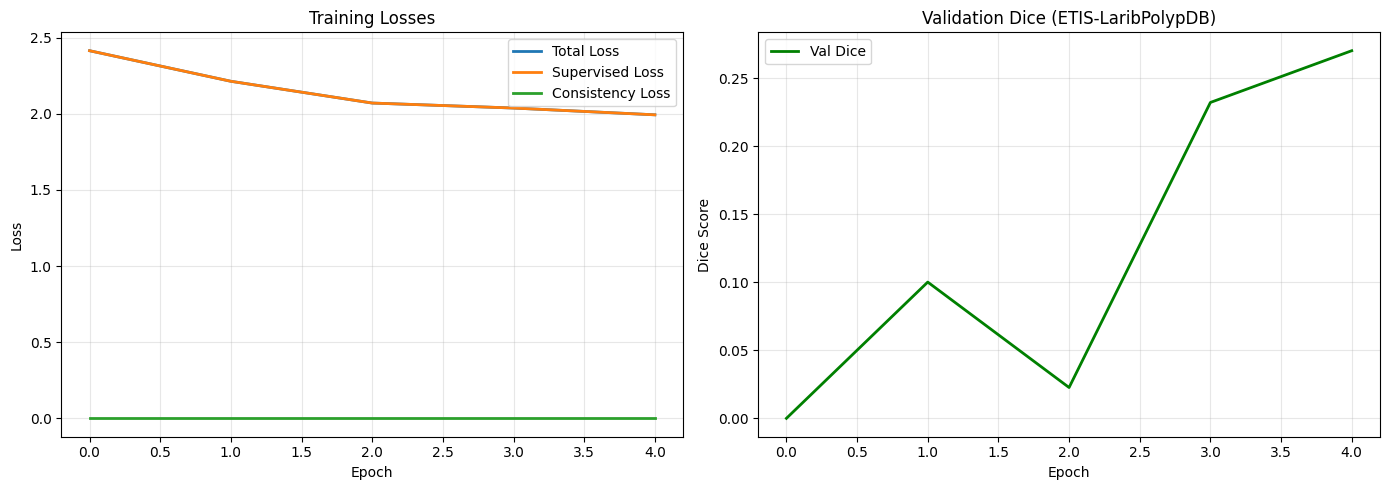

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss curves
ax1.plot(history['train_loss'], label='Total Loss', linewidth=2)
ax1.plot(history['sup_loss'], label='Supervised Loss', linewidth=2)
ax1.plot(history['con_loss'], label='Consistency Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Losses')
ax1.legend()
ax1.grid(True, alpha=0.3)

# dice curve
ax2.plot(history['val_dice'], label='Val Dice', color='green', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.set_title('Validation Dice (ETIS-LaribPolypDB)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## Cell 17: Load Best Model & Full Evaluation
Evaluate on ETIS-LaribPolypDB test set with all metrics.

In [48]:
# load best checkpoint
ckpt = torch.load('best_semidavil.pth', map_location=DEVICE)
model.student_dlg.load_state_dict(ckpt['student_dlg'])
model.student_decoder.load_state_dict(ckpt['student_decoder'])
print(f'Loaded best model from epoch {ckpt["epoch"] + 1}')

# evaluate
model.student_dlg.eval()
model.student_decoder.eval()

all_metrics = {'dice': [], 'iou': [], 'precision': [], 'recall': []}

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs, text_feats, network='student')
        m = compute_metrics(preds, masks)
        for k, v in m.items():
            all_metrics[k].append(v)

# print results
print('\n' + '='*50)
print('ETIS-LaribPolypDB Test Results')
print('='*50)
for k, v in all_metrics.items():
    print(f'{k:>12}: {np.mean(v):.4f} ± {np.std(v):.4f}')
print('='*50)

Loaded best model from epoch 5


Testing:   0%|          | 0/196 [00:00<?, ?it/s]


ETIS-LaribPolypDB Test Results
        dice: 0.2701 ± 0.3418
         iou: 0.2125 ± 0.2878
   precision: 0.6970 ± 0.3845
      recall: 0.3216 ± 0.4102


---
## Cell 18: Visualize Predictions
Show sample images, ground truth, and model predictions side by side.

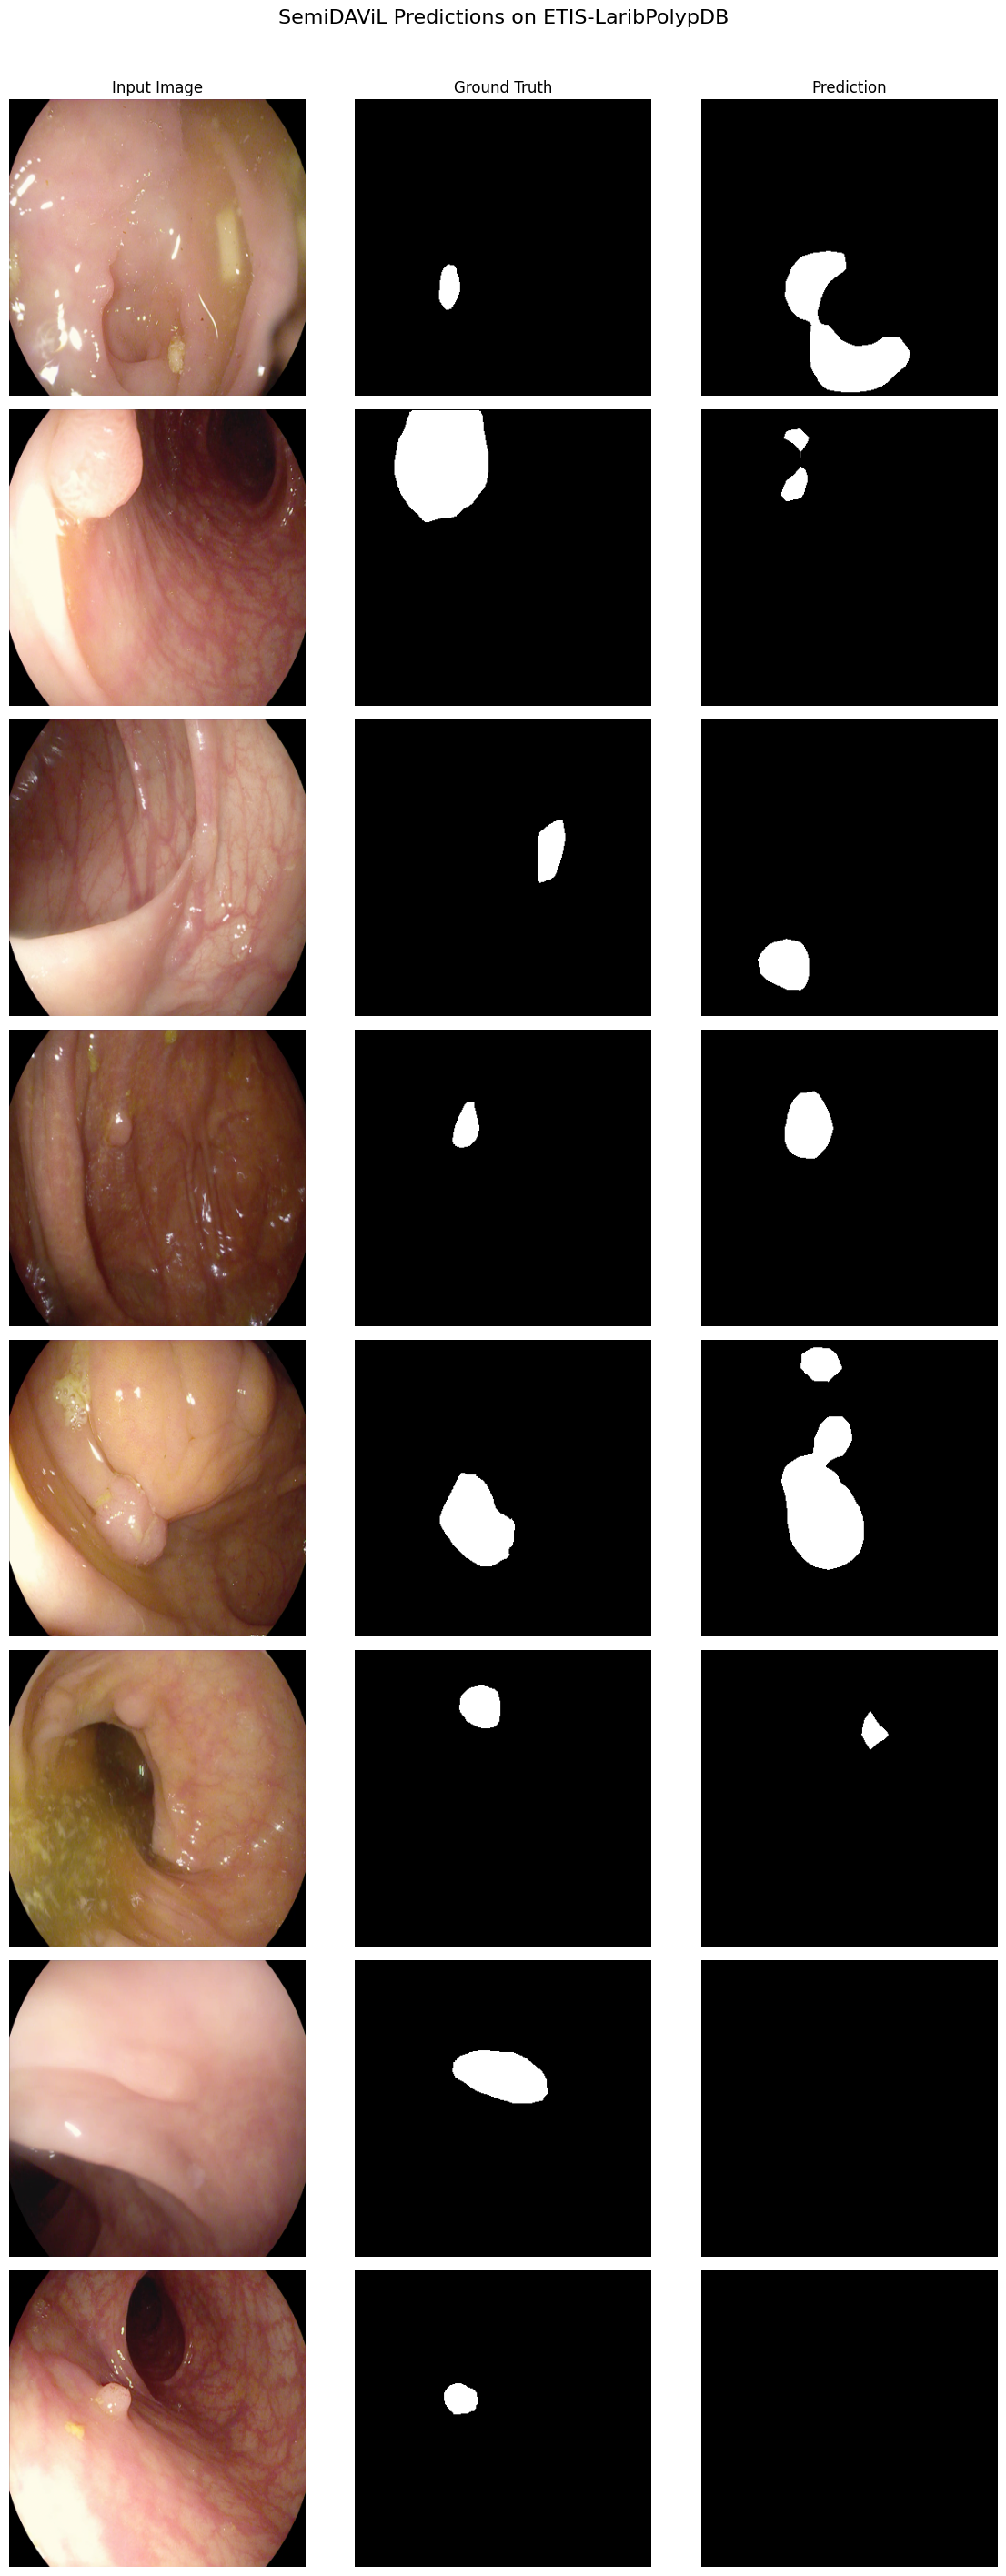

In [49]:
# denormalize helper
def denorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

# pick 8 random test samples
n_show = 8
indices = random.sample(range(len(test_dataset)), min(n_show, len(test_dataset)))

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3.5))
titles = ['Input Image', 'Ground Truth', 'Prediction']

model.student_dlg.eval()
model.student_decoder.eval()

for i, idx in enumerate(indices):
    img, mask = test_dataset[idx]
    img_dev = img.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred = model(img_dev, text_feats, network='student')
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze()
    
    axes[i, 0].imshow(denorm(img))
    axes[i, 1].imshow(mask.squeeze(), cmap='gray')
    axes[i, 2].imshow(pred_mask, cmap='gray')
    
    for j in range(3):
        axes[i, j].set_title(titles[j] if i == 0 else '')
        axes[i, j].axis('off')

plt.suptitle('SemiDAViL Predictions on ETIS-LaribPolypDB', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 19: Overlay Predictions on Images
Overlay predicted polyp masks on original images for visual inspection.

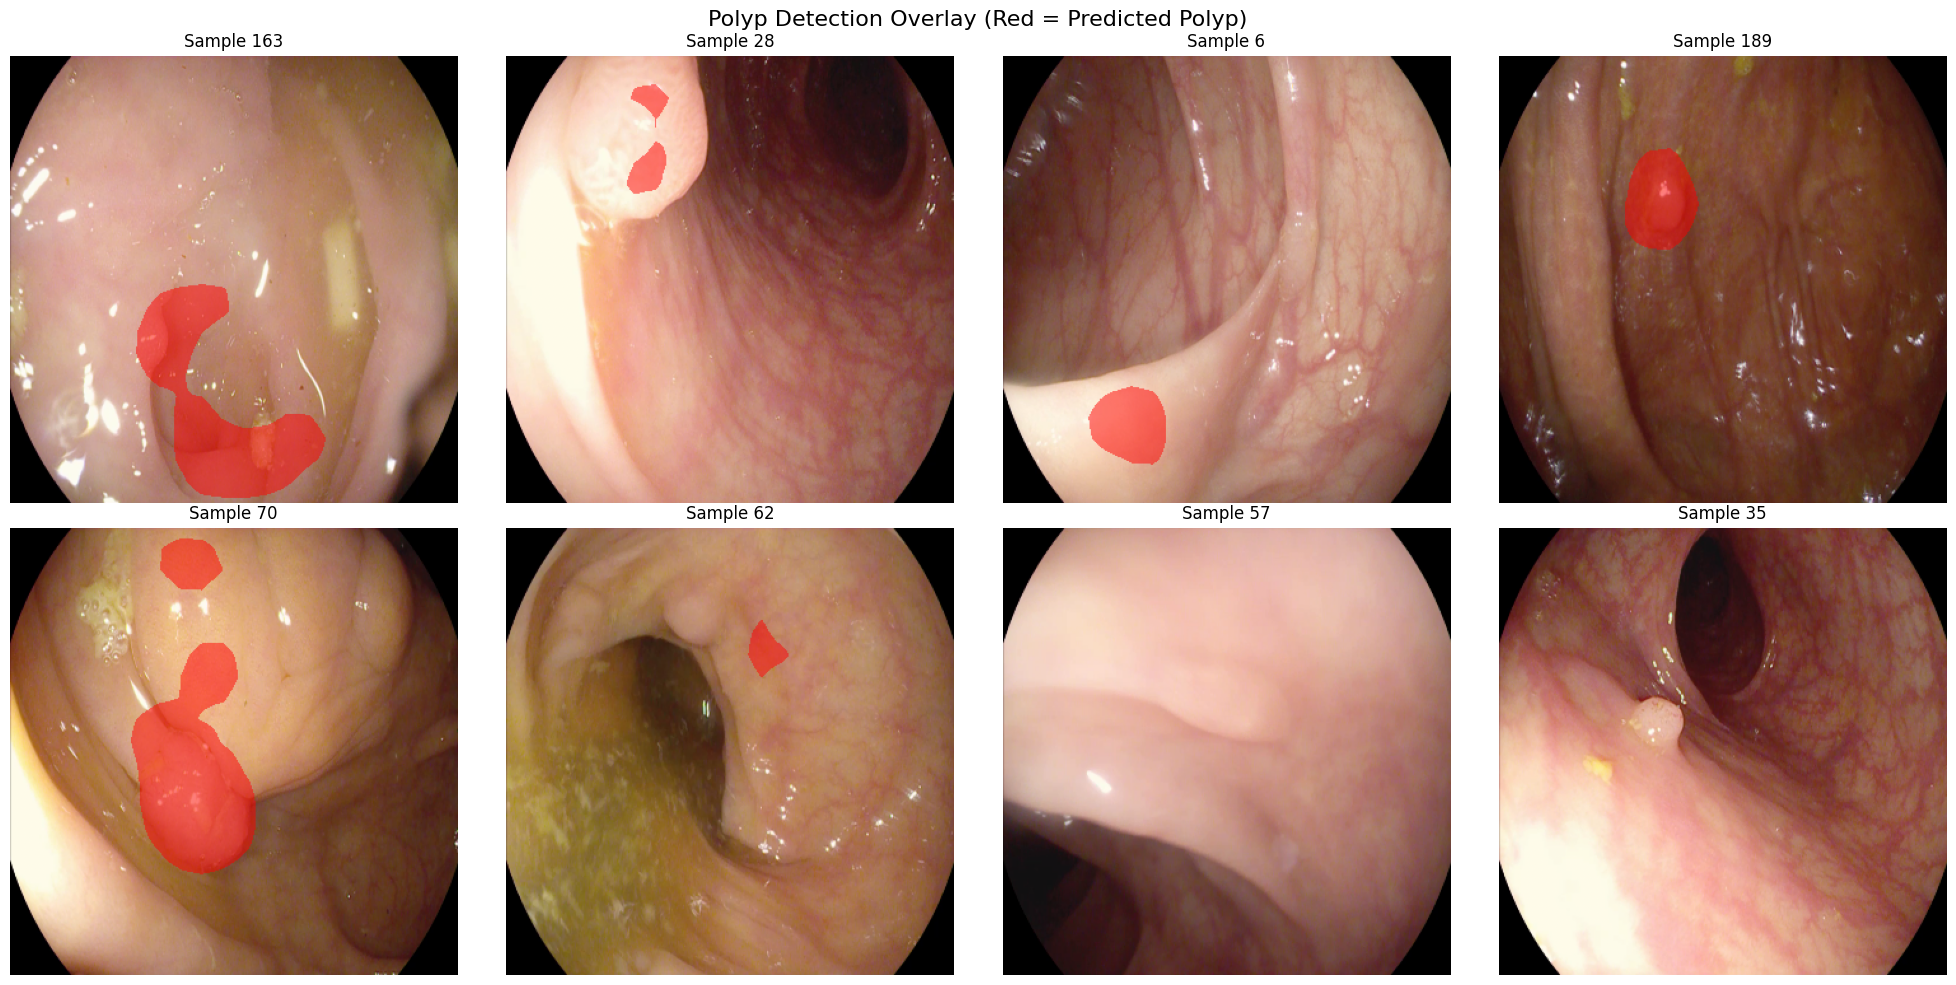

Done! All outputs saved.


In [50]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, idx in enumerate(indices[:8]):
    r, c = i // 4, i % 4
    img, mask = test_dataset[idx]
    img_dev = img.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred = model(img_dev, text_feats, network='student')
        pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()
    
    # overlay prediction in red on image
    img_np = denorm(img)
    overlay = img_np.copy()
    overlay[pred_mask > 0.5] = overlay[pred_mask > 0.5] * 0.5 + np.array([1, 0, 0]) * 0.5
    
    axes[r, c].imshow(overlay)
    axes[r, c].axis('off')
    axes[r, c].set_title(f'Sample {idx}', fontsize=12)

plt.suptitle('Polyp Detection Overlay (Red = Predicted Polyp)', fontsize=16)
plt.tight_layout()
plt.savefig('overlay_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Done! All outputs saved.')